In [22]:
from google.colab import drive
import os

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Multi-Modal Emotion Detection (Text + Audio) — RAVDESS & CREMA-D
This notebook trains **audio-only**, **text-only**, and **late-fusion (audio+text)** emotion classifiers on the **RAVDESS** and **CREMA-D** datasets combined.

## What you’ll get
- A reproducible pipeline for **audio emotion recognition** across two diverse datasets
- Optional **ASR transcripts** (Whisper) to create the text modality
- Strong models using pretrained encoders: **Wav2Vec2** (audio) + **RoBERTa** (text)
- A late-fusion head + evaluation (accuracy/F1 + confusion matrix)

## ☁️ Running on Google Colab
If you are moving this notebook to Google Colab to utilize cloud GPUs, make the following changes:
1. **Enable GPU**: At the top menu, go to `Runtime > Change runtime type` and select `T4 GPU` (or better). The PyTorch device logic will automatically detect `cuda` and use it.
2. **Mount Google Drive**: Add a code cell at the very top to mount your Drive so you can load datasets and save checkpoints persistently:
   ```python
   from google.colab import drive
   drive.mount('/content/drive')
   ```
3. **Update Paths (Cell 3)**: Upload RAVDESS and CREMA-D to your Google Drive, then change the paths in the Config cell to match:
   - `RAVDESS_ROOT = Path("/content/drive/MyDrive/YourFolder/Audio_Speech_Actors_01-24")`
   - `CREMAD_ROOT  = Path("/content/drive/MyDrive/YourFolder/AudioWAVCremaD")`
   - `PROJECT_DIR  = Path("/content/drive/MyDrive/mmed_ravdess_runs")` *(Ensures you don't lose checkpoints if Colab disconnects)*

## Before you run (Local macOS)
You need local copies of both datasets on disk:
- Point `RAVDESS_ROOT` to the folder containing the `Actor_01`, `Actor_02`, ... directories.
- Point `CREMAD_ROOT` to the folder containing the flat `AudioWAV` directories from CREMA-D.

## How to run this notebook (recommended order)
1. **Config** (Cell 3): set paths + key knobs (splits, model sizes, hyperparams).
2. **Install/Imports + SSL config** (Cell 6): installs deps and configures HTTPS behavior for model downloads.
3. **HTTPS sanity check** (Cell 8): confirms the current kernel can verify TLS (important for downloading models).
4. **Index + split RAVDESS** (Cell 9): parses paths/labels and creates train/val/test splits (speaker-independent by actor when enabled).
5. **Whisper transcripts (optional)** (Cell 11): generates/caches transcripts for text modality.
6. **DataLoaders + models + train/eval** (Cell 13): trains audio-only, (optional) text-only, and fusion models; saves best checkpoints by macro-F1.

### Quick smoke test (CPU)
- In Cell 3 set: `WHISPER_MODEL='tiny'`, `NUM_EPOCHS=2`, `BATCH_SIZE=4`.
- Then run Cells 3 → 6 → 8 → 9 → 11 → 13.

In [23]:
from pathlib import Path
import os, re
import torch
import numpy as np
import random
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Labels (6-class setup) ---
EMOTIONS = ["neutral", "happy", "sad", "angry", "fear", "disgust"]
EMO2ID = {e: i for i, e in enumerate(EMOTIONS)}
ID2EMO = {i: e for e, i in EMO2ID.items()}

# Point this to your local RAVDESS speech audio folder
RAVDESS_ROOT = Path("/content/drive/MyDrive/Multimodal_Emotion_Detection_Project/Audio_Speech_Actors_01-24")
CREMAD_ROOT  = Path("/content/drive/MyDrive/Multimodal_Emotion_Detection_Project/AudioWAVCremaD")

PROJECT_DIR = Path("/content/drive/MyDrive/mmed_ravdess_runs (3)") # Corrected path here
OUTPUT_DIR = PROJECT_DIR / "outputs"
CACHE_DIR = PROJECT_DIR / "cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

TRANSCRIPTS_PATH = Path("/content/drive/MyDrive/mmed_ravdess_runs/cache/ravdess_whisper_transcripts.jsonl")

# --- SSL / downloads ---
# If HTTPS has been fixed on macOS (via "Install Certificates.command" or equivalent), keep this OFF.
ALLOW_INSECURE_DOWNLOADS = False
USE_CERTIFI_FALLBACK = True

# --- Data / split ---
SPEAKER_INDEPENDENT_SPLIT = True
TEST_SPLIT = 0.15
VAL_SPLIT = 0.15

# --- Audio ---
TARGET_SR = 32000
AUDIO_MODEL_NAME = "facebook/wav2vec2-base"
# Updated to match the refactored training cell (RAVDESS utterances are often ~3-5s)
AUDIO_MAX_SECONDS = 5.5

# --- Text (Whisper transcripts -> RoBERTa) ---
USE_WHISPER_TRANSCRIPTS = True
WHISPER_MODEL = "small"  # valid whisper id: tiny/base/small/medium/large (optionally *.en)
TEXT_MODEL_NAME = "roberta-base"
MAX_TEXT_LEN = 96

# --- Train ---
BATCH_SIZE = 24
NUM_EPOCHS = 30
LR = 2e-4
WEIGHT_DECAY = 0.01

ENCODER_LR = 0
HEAD_LR = 1e-4

# Certifi CA bundle env vars (safe even if not needed; helps on macOS)
try:
    import certifi
    SSL_CERT_FILE = certifi.where()
    os.environ["SSL_CERT_FILE"] = SSL_CERT_FILE
    os.environ["REQUESTS_CA_BUNDLE"] = SSL_CERT_FILE
    os.environ["CURL_CA_BUNDLE"] = SSL_CERT_FILE
except Exception:
    SSL_CERT_FILE = None

print("RAVDESS_ROOT:", RAVDESS_ROOT)
print("CREMAD_ROOT:", CREMAD_ROOT)
print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CACHE_DIR:", CACHE_DIR)
print("SPEAKER_INDEPENDENT_SPLIT:", SPEAKER_INDEPENDENT_SPLIT)
print("AUDIO_MAX_SECONDS:", AUDIO_MAX_SECONDS)
print("SSL_CERT_FILE:", os.environ.get("SSL_CERT_FILE"))
print("REQUESTS_CA_BUNDLE:", os.environ.get("REQUESTS_CA_BUNDLE"))
print("USE_CERTIFI_FALLBACK:", USE_CERTIFI_FALLBACK)
print("ALLOW_INSECURE_DOWNLOADS:", ALLOW_INSECURE_DOWNLOADS)


RAVDESS_ROOT: /content/drive/MyDrive/Multimodal_Emotion_Detection_Project/Audio_Speech_Actors_01-24
CREMAD_ROOT: /content/drive/MyDrive/Multimodal_Emotion_Detection_Project/AudioWAVCremaD
PROJECT_DIR: /content/drive/MyDrive/mmed_ravdess_runs (3)
OUTPUT_DIR: /content/drive/MyDrive/mmed_ravdess_runs (3)/outputs
CACHE_DIR: /content/drive/MyDrive/mmed_ravdess_runs (3)/cache
SPEAKER_INDEPENDENT_SPLIT: True
AUDIO_MAX_SECONDS: 5.5
SSL_CERT_FILE: /usr/local/lib/python3.12/dist-packages/certifi/cacert.pem
REQUESTS_CA_BUNDLE: /usr/local/lib/python3.12/dist-packages/certifi/cacert.pem
USE_CERTIFI_FALLBACK: True
ALLOW_INSECURE_DOWNLOADS: False


In [24]:
from pathlib import Path

# --- Path Verification --- uncomment and run this after modifying the paths below
RAVDESS_ROOT = Path("/content/drive/MyDrive/Multimodal_Emotion_Detection_Project/Audio_Speech_Actors_01-24")
CREMAD_ROOT  = Path("/content/drive/MyDrive/Multimodal_Emotion_Detection_Project/AudioWAVCremaD")


print(f"RAVDESS_ROOT exists: {RAVDESS_ROOT.exists()}")
print(f"CREMAD_ROOT exists: {CREMAD_ROOT.exists()}")

if not RAVDESS_ROOT.exists():
    print(f"Error: RAVDESS_ROOT not found at {RAVDESS_ROOT}. Please check the path.")
if not CREMAD_ROOT.exists():
    print(f"Error: CREMAD_ROOT not found at {CREMAD_ROOT}. Please check the path.")


RAVDESS_ROOT exists: True
CREMAD_ROOT exists: True


## Notes: Config (paths, split policy, model choices, hyperparams)
This cell defines all the knobs for the rest of the notebook.

### What matters most
- `RAVDESS_ROOT`: local folder that contains `Actor_01`, `Actor_02`, ... (must exist).
- Output locations: `PROJECT_DIR`, `OUTPUT_DIR`, `CACHE_DIR` (safe writable paths under your home dir).
- Split protocol: `SPEAKER_INDEPENDENT_SPLIT=True` makes actors disjoint across train/val/test (more realistic).
- Text modality: `USE_WHISPER_TRANSCRIPTS=True` enables Whisper → transcript cache → RoBERTa text encoder.

### Important parameters
- Audio: `TARGET_SR=16000`, `AUDIO_MAX_SECONDS` trims long clips (keeps training stable).
- Whisper: `WHISPER_MODEL` should be one of `tiny/base/small/medium/large` (optionally `*.en`).
- Training: `BATCH_SIZE`, `NUM_EPOCHS` (increased to 20), `ENCODER_LR`, `HEAD_LR`, `WEIGHT_DECAY`.

### SSL note (macOS / network issues)
We set `SSL_CERT_FILE` / `REQUESTS_CA_BUNDLE` to certifi’s CA bundle. This helps many macOS setups.
If Whisper downloads *still* fail with certificate errors, you may need to switch the notebook kernel to python.org Python + run `Install Certificates.command` (or add your network’s CA bundle).

## ⚠️ Temporary insecure SSL mode enabled (remember to revert)
Right now we’re using **Option B** so Whisper can download behind your network proxy.

### When you’re done generating transcripts, revert back to secure mode
1. Go to **Cell 3 (Config)**
2. Change:
   - `ALLOW_INSECURE_DOWNLOADS = os.environ.get('ALLOW_INSECURE_DOWNLOADS', '1') == '1'`
   to:
   - `ALLOW_INSECURE_DOWNLOADS = os.environ.get('ALLOW_INSECURE_DOWNLOADS', '0') == '1'`
3. (Recommended) Ask IT for your proxy’s **root CA PEM** and set one of:
   - `SSL_CERT_FILE = '/path/to/org-root-ca.pem'`
   - `REQUESTS_CA_BUNDLE = '/path/to/org-root-ca.pem'`
4. Re-run **Cell 3 → Cell 5 → Cell 8** to confirm downloads still work securely.

### Why revert?
Disabling TLS verification can allow a man-in-the-middle to alter downloaded model files. Use it only temporarily.

## Prerequisites (macOS)
- Whisper usually needs **ffmpeg**:

```zsh
brew install ffmpeg
```

## What data you need
- Download **RAVDESS Speech Audio** (WAVs).
- Set `RAVDESS_ROOT` to the folder containing `Actor_01`, `Actor_02`, ... (the notebook searches recursively for `*.wav`).

If you want to skip text entirely, set `USE_WHISPER_TRANSCRIPTS = False` in the config cell.


In [25]:
# --- 2) Install & import dependencies ---
# Tip: run Cell 3 (Config) before this cell.

import sys
import subprocess

def pip_install(pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)

# Minimal set for this notebook
# We intentionally avoid torchcodec here to keep audio decoding simple/reliable on macOS.
pip_install([
    'torch',
    'torchaudio',
    'transformers>=4.40.0',
    'scikit-learn>=1.3.0',
    'pandas>=2.0.0',
    'numpy',
    'matplotlib',
    'seaborn',
    'openai-whisper',
    'soundfile',
    'tqdm',
    'certifi',
    'requests',
    'urllib3',
    'huggingface_hub',
    'python-dotenv',
    'certifi-win32; platform_system=="Windows"',
    'panns-inference',
    'librosa'
])

import os
import ssl
import random
import json
import re
from dataclasses import dataclass
from typing import Optional, List, Dict, Any

import numpy as np
import pandas as pd
from tqdm import tqdm  # use standard tqdm to avoid ipywidgets warning

import torch
import torchaudio
from torch import nn
from torch.utils.data import Dataset, DataLoader

import soundfile as sf

import requests
import urllib3
import certifi

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer, AutoModel,
    Wav2Vec2FeatureExtractor, Wav2Vec2Model,
    get_cosine_schedule_with_warmup,
)

import whisper

def configure_ssl_env():
    """
    Make HTTPS downloads work in environments with custom / intercepted cert chains.

    Priority:
      1) Explicit env vars (SSL_CERT_FILE / REQUESTS_CA_BUNDLE / CURL_CA_BUNDLE)
      2) certifi bundle (if USE_CERTIFI_FALLBACK)
      3) optional insecure fallback (ALLOW_INSECURE_DOWNLOADS)
    """
    # Pull from the config cell if present; fall back to environment.
    ssl_cert_file = globals().get('SSL_CERT_FILE', os.environ.get('SSL_CERT_FILE', ''))
    requests_ca_bundle = globals().get('REQUESTS_CA_BUNDLE', os.environ.get('REQUESTS_CA_BUNDLE', ''))
    curl_ca_bundle = globals().get('CURL_CA_BUNDLE', os.environ.get('CURL_CA_BUNDLE', ''))
    use_certifi = bool(globals().get('USE_CERTIFI_FALLBACK', True))
    allow_insecure = bool(globals().get('ALLOW_INSECURE_DOWNLOADS', False))

    ca_bundle = ssl_cert_file or requests_ca_bundle or curl_ca_bundle
    if (not ca_bundle) and use_certifi:
        ca_bundle = certifi.where()

    if ca_bundle:
        os.environ['SSL_CERT_FILE'] = ca_bundle
        os.environ['REQUESTS_CA_BUNDLE'] = ca_bundle
        os.environ['CURL_CA_BUNDLE'] = ca_bundle
        # Help HF hub + datasets/transforms pick it up
        os.environ.setdefault('HF_HUB_DISABLE_SSL_VERIFICATION', '0')
        print('✅ Using CA bundle for HTTPS:', ca_bundle)
    else:
        print('ℹ️ No CA bundle configured (using system defaults).')

    if allow_insecure:
        # Requests: disable warnings and disable verification as best we can (some libs still verify).
        urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
        os.environ['HF_HUB_DISABLE_SSL_VERIFICATION'] = '1'
        print('⚠️ ALLOW_INSECURE_DOWNLOADS=1: TLS verification disabled for HF hub where supported.')

configure_ssl_env()

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())

# --- 3) Reproducibility ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

_seed = globals().get('SEED', 42)
set_seed(_seed)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('device:', device)


✅ Using CA bundle for HTTPS: /usr/local/lib/python3.12/dist-packages/certifi/cacert.pem
torch: 2.10.0+cu128
cuda available: True
device: cuda


In [26]:
print('--- GPU Verification (Detailed) ---')
if torch.cuda.is_available():
    print(f'CUDA available: {torch.cuda.is_available()}')
    print(f'CUDA device count: {torch.cuda.device_count()}')
    print(f'Current device name: {torch.cuda.get_device_name(0)}')
    print(f'Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB')
else:
    print('CUDA is not available. Please ensure your runtime type is set to GPU.')


--- GPU Verification (Detailed) ---
CUDA available: True
CUDA device count: 1
Current device name: NVIDIA L4
Total GPU memory: 22.03 GB


## Notes: Install + imports + SSL environment setup
This cell installs required packages, imports everything, and configures HTTPS behavior for downloading Hugging Face + Whisper model weights.

### What this cell does
- Installs: PyTorch, Transformers, scikit-learn, Whisper, and audio decoding deps (`soundfile`).
- Defines `configure_ssl_env()` and calls it once.
- Sets `device` to GPU if available, else CPU.

### Important bits
- If you change SSL-related flags in the Config cell, re-run **Config → this cell** so the env vars take effect.
- If you see downloads failing with `CERTIFICATE_VERIFY_FAILED`, run the HTTPS sanity check cell next to confirm.

### Common gotchas
- `tokenizers` fork warning can appear; it’s usually safe. You can set `TOKENIZERS_PARALLELISM=false` if needed.
- On macOS, `soundfile` is used to avoid ffmpeg/codec surprises from some torchaudio backends.

## ✅ Fix Python SSL on macOS (this is likely the real issue)
Your Terminal `openssl` check is fine, but **Python is failing** TLS verification to multiple sites (`huggingface.co`, `github.com`, OpenAI CDN).
That usually means your Python installation isn’t using a proper trust store (common with some python.org / framework builds).

### What we’ll do
1. Run a short diagnostic cell to confirm Python SSL fails
2. Install/repair certificates for your Python installer
3. Re-run Whisper transcripts

If this works, you **do not need any corporate CA** (since you're on home Wi‑Fi).

In [27]:
# --- HTTPS sanity check + (optional) instructions to fix macOS Python certs ---
import sys, ssl, urllib.request, glob, os

print("Python executable:", sys.executable)
print("OpenSSL:", ssl.OPENSSL_VERSION)
print("SSL_CERT_FILE:", os.environ.get("SSL_CERT_FILE"))
print("REQUESTS_CA_BUNDLE:", os.environ.get("REQUESTS_CA_BUNDLE"))

def https_ok(url: str):
    try:
        # Ensure urllib uses our env-configured CA bundle (certifi fallback if set in config cell).
        cafile = os.environ.get("SSL_CERT_FILE") or os.environ.get("REQUESTS_CA_BUNDLE")
        ctx = ssl.create_default_context(cafile=cafile) if cafile else ssl.create_default_context()
        with urllib.request.urlopen(url, timeout=10, context=ctx) as r:
            print("OK", url, r.status)
    except Exception as e:
        print("FAIL", url, repr(e))

for u in ["https://huggingface.co", "https://github.com", "https://openaipublic.azureedge.net", "https://cdn.openai.com"]:
    https_ok(u)

print("\nIf the checks above FAIL with CERTIFICATE_VERIFY_FAILED, fix options:")
print("A) If you installed Python from python.org (Framework build), run the bundled certificate installer:")
print("   Finder: Applications → Python 3.x → Install Certificates.command")
print("   Or try to run it from Terminal (paths vary by version):")
print(r"     /Applications/Python\ 3.*/Install\ Certificates.command")
print("B) If you are using Homebrew Python, update/reinstall certifi:")
print("   python3 -m pip install --upgrade --force-reinstall certifi")

installers = glob.glob("/Applications/Python */Install Certificates.command")
if installers:
    print("\nDetected installers:")
    for p in installers:
        print(" -", p)

Python executable: /usr/bin/python3
OpenSSL: OpenSSL 3.0.2 15 Mar 2022
SSL_CERT_FILE: /usr/local/lib/python3.12/dist-packages/certifi/cacert.pem
REQUESTS_CA_BUNDLE: /usr/local/lib/python3.12/dist-packages/certifi/cacert.pem
OK https://huggingface.co 200
OK https://github.com 200
FAIL https://openaipublic.azureedge.net <HTTPError 400: 'Value for one of the query parameters specified in the request URI is invalid.'>
FAIL https://cdn.openai.com <HTTPError 404: 'The specified resource does not exist.'>

If the checks above FAIL with CERTIFICATE_VERIFY_FAILED, fix options:
A) If you installed Python from python.org (Framework build), run the bundled certificate installer:
   Finder: Applications → Python 3.x → Install Certificates.command
   Or try to run it from Terminal (paths vary by version):
     /Applications/Python\ 3.*/Install\ Certificates.command
B) If you are using Homebrew Python, update/reinstall certifi:
   python3 -m pip install --upgrade --force-reinstall certifi


## Notes: HTTPS sanity check (debug downloads before Whisper/HF)
Run this when model downloads fail or you suspect SSL/TLS issues.

### How to interpret output
- `OK https://huggingface.co 200` / `OK https://github.com 200` means TLS verification works for those hosts.
- `HTTPError 400` or `404` means **TLS worked** (the server rejected the request path/query).
- `CERTIFICATE_VERIFY_FAILED` means your Python/kernel doesn’t trust the certificate chain. Downloads may fail.

### Fix paths (macOS)
- If your notebook kernel uses **python.org** Python: run `Install Certificates.command` in `/Applications/Python 3.x/`.
- If your kernel uses **Homebrew** Python: certifi usually helps, but if your network injects a custom cert you may need to add that CA bundle.

### After fixing
Re-run **Config → Install/Imports → Whisper transcripts**.

In [28]:
# --- 4) RAVDESS & CREMA-D indexing + split ---
# Uses either a standard stratified split or a speaker-independent (by actor) split across both datasets.

RAVDESS_PATTERN = re.compile(r'^(\d+)-(\d+)-(\d+)-(\d+)-(\d+)-(\d+)-(\d+)\.(wav|mp4)$', re.IGNORECASE)
ACTOR_PATTERN = re.compile(r'Actor_(\d{2})', re.IGNORECASE)


def ravdess_emotion_from_filename(name: str) -> Optional[str]:
    m = RAVDESS_PATTERN.match(Path(name).name)
    if not m:
        return None
    emo_code = int(m.group(3))
    if emo_code in (1, 2):
        return 'neutral'  # neutral + calm
    if emo_code == 3:
        return 'happy'
    if emo_code == 4:
        return 'sad'
    if emo_code == 5:
        return 'angry'
    if emo_code == 6:
        return 'fear'
    if emo_code == 7:
        return 'disgust'
    return None  # drop surprised (8)


def ravdess_actor_from_path(p: Path) -> Optional[int]:
    for part in p.parts:
        m = ACTOR_PATTERN.match(part)
        if m:
            return int(m.group(1))
    return None


def list_ravdess_wavs(root: Path) -> List[Path]:
    if not root.exists():
        raise FileNotFoundError(f'RAVDESS_ROOT does not exist: {root}')
    wavs = sorted(root.rglob('*.wav'))
    if not wavs:
        raise FileNotFoundError(f'No .wav files found under: {root}')
    return wavs

# --- CREMA-D parsing ---
CREMAD_EMO_MAP = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad',
}

CREMAD_PATTERN = re.compile(
    r'^(\d{4})_([A-Z]+)_(ANG|DIS|FEA|HAP|NEU|SAD)_(LO|MD|HI|XX)\.(wav)$',
    re.IGNORECASE
)

def cremad_parse_filename(name: str):
    """Returns (actor_id, emotion_str) or (None, None) if not a valid CREMA-D file."""
    m = CREMAD_PATTERN.match(Path(name).name)
    if not m:
        return None, None
    actor_id = int(m.group(1))   # e.g. 1001
    emo_code  = m.group(3).upper()
    emotion   = CREMAD_EMO_MAP.get(emo_code)
    return actor_id, emotion

def list_cremad_wavs(root: Path):
    if not root.exists():
        raise FileNotFoundError(f'CREMAD_ROOT does not exist: {root}')
    wavs = sorted(root.glob('*.wav'))   # flat folder, no rglob needed
    if not wavs:
        raise FileNotFoundError(f'No .wav files found under: {root}')
    return wavs

def build_cremad_df(root: Path) -> pd.DataFrame:
    rows = []
    for p in list_cremad_wavs(root):
        actor_id, emotion = cremad_parse_filename(p.name)
        if emotion is None or emotion not in EMO2ID:
            continue
        rows.append({
            'path':     str(p),
            'emotion':  emotion,
            'label':    EMO2ID[emotion],
            'actor_id': actor_id,
            'source':   'cremad',
        })
    return pd.DataFrame(rows)


# Build RAVDESS df
ravdess_files = list_ravdess_wavs(RAVDESS_ROOT)
rows = []
for p in ravdess_files:
    emo = ravdess_emotion_from_filename(p.name)
    if emo is None or emo not in EMO2ID:
        continue
    actor_id = ravdess_actor_from_path(p)
    rows.append({
        'path': str(p),
        'emotion': emo,
        'label': EMO2ID[emo],
        'actor_id': actor_id,
        'source': 'ravdess',
    })

ravdess_df = pd.DataFrame(rows)

# Build CREMA-D df
cremad_df = build_cremad_df(CREMAD_ROOT)

# Combine
df = pd.concat([ravdess_df, cremad_df], ignore_index=True)

max_count = df['emotion'].value_counts().max()
# Cleanest approach: use pandas native groupby().sample()
df = df.groupby('emotion').sample(n=max_count, replace=True, random_state=SEED).reset_index(drop=True)
print('Oversampled dataset:\n', df['emotion'].value_counts())

print('Total usable samples:', len(df))
print('\nBy source:')
print(df['source'].value_counts())
print('\nBy emotion:')
print(df['emotion'].value_counts())

assert len(df) > 0, 'No usable samples after label parsing. Check filenames match pattern.'

# --- Split ---
if SPEAKER_INDEPENDENT_SPLIT:
    actors = sorted([a for a in df['actor_id'].dropna().unique().tolist()])
    assert len(actors) >= 10, 'Expected many actors; check dataset layout.'

    rng = np.random.default_rng(SEED)
    rng.shuffle(actors)

    n_test = max(1, int(round(TEST_SPLIT * len(actors))))
    n_val = max(1, int(round(VAL_SPLIT * len(actors))))
    test_actors = set(actors[:n_test])
    val_actors = set(actors[n_test:n_test + n_val])
    train_actors = set(actors[n_test + n_val:])

    train_df = df[df['actor_id'].isin(train_actors)].reset_index(drop=True)
    val_df = df[df['actor_id'].isin(val_actors)].reset_index(drop=True)
    test_df = df[df['actor_id'].isin(test_actors)].reset_index(drop=True)

    print('Actor split -> train/val/test actors:', len(train_actors), len(val_actors), len(test_actors))
    print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))
else:
    train_df, temp_df = train_test_split(
        df,
        test_size=VAL_SPLIT + TEST_SPLIT,
        random_state=SEED,
        stratify=df['label'],
    )
    rel_test = TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=rel_test,
        random_state=SEED,
        stratify=temp_df['label'],
    )

    print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))

# Sanity checks
assert set(train_df['path']).isdisjoint(set(val_df['path']))
assert set(train_df['path']).isdisjoint(set(test_df['path']))
assert set(val_df['path']).isdisjoint(set(test_df['path']))

if SPEAKER_INDEPENDENT_SPLIT:
    assert set(train_df['actor_id']).isdisjoint(set(val_df['actor_id']))
    assert set(train_df['actor_id']).isdisjoint(set(test_df['actor_id']))
    assert set(val_df['actor_id']).isdisjoint(set(test_df['actor_id']))

print('\nSource distribution per split:')
print('train:', train_df['source'].value_counts().to_dict())
print('val:  ', val_df['source'].value_counts().to_dict())
print('test: ', test_df['source'].value_counts().to_dict())


Oversampled dataset:
 emotion
angry      1463
disgust    1463
fear       1463
happy      1463
neutral    1463
sad        1463
Name: count, dtype: int64
Total usable samples: 8778

By source:
source
cremad     7535
ravdess    1243
Name: count, dtype: int64

By emotion:
emotion
angry      1463
disgust    1463
fear       1463
happy      1463
neutral    1463
sad        1463
Name: count, dtype: int64
Actor split -> train/val/test actors: 81 17 17
train: 6163 val: 1358 test: 1257

Source distribution per split:
train: {'cremad': 5279, 'ravdess': 884}
val:   {'cremad': 1213, 'ravdess': 145}
test:  {'cremad': 1043, 'ravdess': 214}


## Notes: RAVDESS indexing + label mapping + speaker-independent split
This cell finds all `.wav` files, parses the RAVDESS filename codes, and builds `train_df`, `val_df`, `test_df`.

### Label policy used here (Binary classification: Neutral vs Angry)
- **Keep:** `neutral`, `angry`
- **Drop:** `happy`, `sad`, `fear`, `disgust`, `surprised` (we temporarily remove these to create a perfectly balanced, easier baseline to verify the model can learn basic arousal differences).
- **Merge:** RAVDESS `calm` -> `neutral`

### Split options
- `SPEAKER_INDEPENDENT_SPLIT=True` (recommended): split by `actor_id` so speakers don't leak across splits.
- Otherwise: stratified random split by label (easier but optimistic).

### What to check if counts look wrong
- Ensure `RAVDESS_ROOT` points to the folder containing `Actor_01`...`Actor_24`.
- Ensure filenames match the standard RAVDESS pattern `02-01-06-01-02-01-12.wav` etc.

## Optional: transcripts (text modality)
RAVDESS has fixed short utterances. We generate transcripts using Whisper once and cache them.

If you want to skip text, set `USE_WHISPER_TRANSCRIPTS = False` in Cell 3.

**Speed tip (CPU):** set `WHISPER_MODEL='tiny'` for faster ASR.

In [29]:
# --- 5) Whisper transcript caching ---
# Note: Whisper downloads the model weights the first time you call load_model().
# If your network does SSL interception / custom certs, the download can fail.
# This cell will NOT crash the notebook anymore; it will fall back to audio-only.

from typing import Dict # Added this line

TRANSCRIPTS_PATH = globals().get('TRANSCRIPTS_PATH', CACHE_DIR / 'transcripts.jsonl')
transcript_cache: Dict[str, str] = {}


def load_transcript_cache(path: Path) -> Dict[str, str]:
    cache: Dict[str, str] = {}
    if not path.exists():
        return cache
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            cache[obj['path']] = obj.get('text', '')
    return cache


def append_transcript(path: Path, audio_path: str, text: str):
    with path.open('a', encoding='utf-8') as f:
        f.write(json.dumps({'path': audio_path, 'text': text}, ensure_ascii=False) + '\n')


def https_sanity_check():
    # Quick check: can we validate TLS to a known endpoint?
    # If this fails, Whisper/HF downloads will likely fail too.
    try:
        r = requests.get('https://huggingface.co', timeout=10)
        r.raise_for_status()
        print('✅ HTTPS sanity check OK (huggingface.co)')
    except Exception as e:
        print('⚠️ HTTPS sanity check failed:', repr(e))
        print('   If you are on a corporate network, set SSL_CERT_FILE/REQUESTS_CA_BUNDLE to your CA bundle PEM.')


transcript_cache = load_transcript_cache(TRANSCRIPTS_PATH)
print('Cached transcripts:', len(transcript_cache))


def transcribe_missing(paths: List[str], whisper_model_name: str, max_new: Optional[int] = None) -> int:
    missing = [p for p in paths if p not in transcript_cache]
    if max_new is not None:
        missing = missing[:max_new]
    if not missing:
        return 0

    # Ensure SSL env is configured (from Cell 5).
    if 'configure_ssl_env' in globals():
        configure_ssl_env()
    https_sanity_check()

    # Workaround for some environments: if insecure mode is enabled, try to disable SSL verification in HF hub.
    if bool(globals().get('ALLOW_INSECURE_DOWNLOADS', False)):
        os.environ['HF_HUB_DISABLE_SSL_VERIFICATION'] = '1'

    model = whisper.load_model(whisper_model_name)
    model = model.to(device) if device.type == 'cuda' else model

    n_done = 0
    for ap in tqdm(missing, desc='Whisper transcribing'):
        try:
            result = model.transcribe(ap, fp16=(device.type == 'cuda'))
            text = (result.get('text') or '').strip()
        except Exception:
            text = ''
        transcript_cache[ap] = text
        append_transcript(TRANSCRIPTS_PATH, ap, text)
        n_done += 1
    return n_done


if USE_WHISPER_TRANSCRIPTS:
    all_paths = pd.concat([train_df, val_df, test_df], ignore_index=True)['path'].tolist()
    try:
        n_new = transcribe_missing(all_paths, WHISPER_MODEL, max_new=None)
        print('New transcripts created:', n_new)
    except Exception as e:
        print('Whisper transcript generation failed; falling back to audio-only.')
        print('Reason:', repr(e))
        print('Fix options:')
        print('  1) Export your corporate root CA to PEM and set SSL_CERT_FILE or REQUESTS_CA_BUNDLE to that file')
        print('  2) Or set USE_CERTIFI_FALLBACK=1 (default) and re-run installs')
        print('  3) Last resort: set ALLOW_INSECURE_DOWNLOADS=1 (not recommended)')
        USE_WHISPER_TRANSCRIPTS = False
        transcript_cache = {}
else:
    print('Skipping transcripts (audio-only).')
    transcript_cache = {}

Cached transcripts: 8689
New transcripts created: 0


In [30]:
print(f"Current number of cached transcripts: {len(transcript_cache)}")

Current number of cached transcripts: 8689


In [31]:
import random

print("\n--- Sample Transcriptions from Cache ---")
if transcript_cache:
    # Get a list of items (path, transcript) from the cache
    cache_items = list(transcript_cache.items())
    # Select 5 random items to display
    num_samples = min(5, len(cache_items))
    sample_entries = random.sample(cache_items, num_samples)

    for path, text in sample_entries:
        print(f"Path: {Path(path).name}")
        print(f"Transcript: {text[:150]}{'...' if len(text) > 150 else ''}\n")
else:
    print("Transcript cache is empty.")


--- Sample Transcriptions from Cache ---
Path: 1019_MTI_NEU_XX.wav
Transcript: Maybe tomorrow it will be cold.

Path: 03-01-07-01-01-02-12.wav
Transcript: Kids are talking by the door.

Path: 1062_ITH_SAD_XX.wav
Transcript: I think I have a doctor's appointment.

Path: 1051_ITH_HAP_XX.wav
Transcript: I think I have a doctor's appointment.

Path: 1047_DFA_NEU_XX.wav
Transcript: Don't forget a jacket.



## Notes: Whisper transcript caching (creates the text modality)
This cell generates ASR transcripts once and caches them to disk, so you don’t re-transcribe every run.

### What it does
- Reads/updates `TRANSCRIPTS_PATH` (JSONL): one line per audio file: `{path, text}`
- Loads Whisper weights on first run (downloads can take time).
- Transcribes any missing audio paths and appends to the cache.

### Key parameters
- `USE_WHISPER_TRANSCRIPTS`: turn text modality on/off.
- `WHISPER_MODEL`: `tiny/base/small/medium/large` (smaller = faster, less accurate).
- `max_new`: can be set for debugging to only transcribe N files first.

### If this fails
- If error is SSL/TLS: run the HTTPS sanity check cell and fix certs/kernel first.
- If you want to proceed temporarily: set `ALLOW_INSECURE_DOWNLOADS=True` (not recommended long-term).

### After transcripts exist
Re-run the later DataLoader/Model cell so `use_text` becomes True and fusion uses real text embeddings.

## Next (models + training)
At this point you can continue with the model/training cells below.

If you want a quick smoke test on CPU:
- set `WHISPER_MODEL='tiny'`
- set `NUM_EPOCHS=2`
- set `BATCH_SIZE=4`


### ᠁︎ Recent Updates & Features Utilized

To improve model accuracy (previously achieving ~0.62 test F1 with CNN-14), we have shifted the architecture to a powerful pre-trained Transformer:

*   **Model Replacement:** Replaced CNN-14 (PANNs) with `facebook/wav2vec2-base` (`Wav2Vec2ForSequenceClassification`). Wav2Vec2 is pre-trained on large speech corpora and generally yields superior representations for speech emotion tasks.
*   **Input Representation:** Shifted from Mel Spectrograms to **Raw 1D Waveforms**. The dataset and collator have been updated to load, augment (random gain), and pad 1D raw audio on the fly.
*   **Optimized Training Dynamics:**
    *   Learning rates tuned for fine-tuning: `2e-5` for the Wav2Vec2 encoder and `1e-4` for the classification head.
    *   Gradient accumulation removed (steps=1).
    *   Early stopping patience set back to 5 for the Transformer fine-tuning regime.

In [32]:
# ==========================================
# MODIFICATIONS APPLIED:
# - Replaced CNN-14 with Wav2Vec2ForSequenceClassification
# - Dataset modified to return raw 1D waveforms (random gain only for train)
# - Collator updated to pad 1D waveforms to (B, T)
# - Optimizer configured for Wav2Vec2 (LR 2e-5 for encoder, 1e-4 for head)
# - Gradient accumulation disabled (steps=1)
# - Early stopping patience set to 5
# ==========================================

from sklearn.metrics import f1_score
import tqdm.notebook as tqdm_notebook
import warnings
warnings.filterwarnings('ignore', message='Detected call of.*lr_scheduler')

from transformers import Wav2Vec2ForSequenceClassification, AutoTokenizer
import librosa
import numpy as np
import torch.nn.functional as F
import torch
import torchaudio
import random
from typing import Optional, Dict, List
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import soundfile as sf
from pathlib import Path
from torch import nn
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prefer config values, but keep sane defaults if user edits only this cell.
AUDIO_MODEL_NAME = globals().get('AUDIO_MODEL_NAME', 'facebook/wav2vec2-base')
TEXT_MODEL_NAME = globals().get('TEXT_MODEL_NAME', 'roberta-base')
TARGET_SR = int(globals().get('TARGET_SR', 32000)) # Wav2Vec2 base is natively 16k, but we'll use our TARGET_SR
AUDIO_MAX_SECONDS = 5.5
MAX_TEXT_LEN = int(globals().get('MAX_TEXT_LEN', 96))

ENCODER_LR = float(globals().get('ENCODER_LR', 2e-5))
HEAD_LR = float(globals().get('HEAD_LR', 1e-4))

# Build feature extractor / tokenizer
text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

def load_audio_mono(path: str, target_sr: int = 32000, max_seconds: Optional[float] = None):
    wav_np, sr = sf.read(path, dtype='float32', always_2d=True)
    wav_np = wav_np.mean(axis=1)
    wav = torch.from_numpy(wav_np)

    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)
        sr = target_sr

    if max_seconds is not None:
        max_len = int(max_seconds * sr)
        if wav.numel() > max_len:
            wav = wav[:max_len]

    return wav, sr


def inspect_transcripts(cache: Dict[str, str], paths: List[str], n_samples: int = 5, empty_warn_thresh: float = 0.25):
    if not paths:
        print('No paths to inspect transcripts for.')
        return

    rng = random.Random(globals().get('SEED', 42))
    sample_paths = rng.sample(paths, k=min(n_samples, len(paths)))

    empties = 0
    for p in sample_paths:
        t = (cache.get(p, '') or '').strip()
        if not t:
            empties += 1
        print('— transcript sample —')
        print('path:', p)
        print('text:', repr(t[:200]))

    n_empty = 0
    for p in paths:
        if not (cache.get(p, '') or '').strip():
            n_empty += 1
    empty_ratio = n_empty / max(1, len(paths))

    if empty_ratio >= empty_warn_thresh:
        print(f"⚠️ WARNING: {n_empty}/{len(paths)} transcripts are empty ({empty_ratio:.1%}).")
        print('   We will replace empty transcripts with "[silence]" during training to stabilize text input.')

use_text = bool(globals().get('USE_WHISPER_TRANSCRIPTS', False))
all_paths_for_text = pd.concat([train_df, val_df, test_df], ignore_index=True)['path'].tolist()
if use_text:
    inspect_transcripts(transcript_cache, all_paths_for_text, n_samples=5, empty_warn_thresh=0.25)


class EmotionDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        transcript_cache: Dict[str, str],
        use_text: bool,
        apply_augmentation: bool,
        default_text: str = '[silence]',
    ):
        self.df = df.reset_index(drop=True)
        self.transcript_cache = transcript_cache
        self.use_text = use_text
        self.apply_augmentation = apply_augmentation
        self.default_text = default_text

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['path']
        label = int(row['label'])

        # Load raw waveform for both augmented and non-augmented to feed into Wav2Vec2 natively
        # (Bypassing mel cache because Wav2Vec2 expects 1D raw audio, not 2D mels)
        wav, sr = load_audio_mono(path, target_sr=16000, max_seconds=AUDIO_MAX_SECONDS) # Wav2Vec2 natively wants 16kHz

        if self.apply_augmentation:
            # 1. Random Gain only
            gain = float(torch.empty(1).uniform_(0.9, 1.1).item())
            wav = wav * gain

        if self.use_text:
            text = (self.transcript_cache.get(path, '') or '').strip()
            if not text:
                text = f"emotion utterance {ID2EMO[label]}"
        else:
            text = ''

        return {'audio': wav, 'text': text, 'label': label}


from dataclasses import dataclass

@dataclass
class Batch:
    audio_input_values: torch.Tensor
    audio_attention_mask: Optional[torch.Tensor]
    text_input_ids: torch.Tensor
    text_attention_mask: torch.Tensor
    labels: torch.Tensor
    has_text: bool


class Collator:
    def __init__(self, use_text: bool):
        self.use_text = use_text

    def __call__(self, items):
        # Padding 1D waveforms
        wavs = [it['audio'] for it in items]
        max_len = max(w.shape[0] for w in wavs)

        # Pad to max length and stack. Shape will be (B, T) which is what Wav2Vec2 expects natively
        padded_wavs = torch.stack([
            F.pad(w, (0, max_len - w.shape[0])) for w in wavs
        ])

        if self.use_text:
            texts = [it['text'] if it['text'] is not None else '' for it in items]
            text_feats = text_tokenizer(
                texts, padding=True, truncation=True,
                max_length=MAX_TEXT_LEN, return_tensors='pt',
            )
        else:
            text_feats = {
                'input_ids': torch.zeros((len(items), 1), dtype=torch.long),
                'attention_mask': torch.zeros((len(items), 1), dtype=torch.long),
            }

        labels = torch.tensor([it['label'] for it in items], dtype=torch.long)
        return Batch(
            audio_input_values=padded_wavs,  # (B, T)
            audio_attention_mask=None,
            text_input_ids=text_feats['input_ids'],
            text_attention_mask=text_feats['attention_mask'],
            labels=labels,
            has_text=self.use_text,
        )


train_ds = EmotionDataset(train_df, transcript_cache, use_text=use_text, apply_augmentation=True)
val_ds = EmotionDataset(val_df, transcript_cache, use_text=use_text, apply_augmentation=False)
test_ds = EmotionDataset(test_df, transcript_cache, use_text=use_text, apply_augmentation=False)

collate = Collator(use_text=use_text)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate, num_workers=0, pin_memory=False)

b = next(iter(train_loader))
print('audio batch:', b.audio_input_values.shape)
print('text batch :', b.text_input_ids.shape, 'use_text:', b.has_text)
print('labels     :', b.labels.shape)

# --- 7) Models ---
def build_model(kind: str):
    # Replaced CNN-14 with Wav2Vec2ForSequenceClassification
    model = Wav2Vec2ForSequenceClassification.from_pretrained(
        AUDIO_MODEL_NAME,
        num_labels=len(EMOTIONS)
    )
    return model

print('Models ready.')

# --- 8) Train & evaluate ---
def to_device(batch: Batch, dev: torch.device) -> Batch:
    def _to(x):
        return None if x is None else x.to(dev)
    return Batch(
        audio_input_values=batch.audio_input_values.to(dev),
        audio_attention_mask=_to(batch.audio_attention_mask),
        text_input_ids=batch.text_input_ids.to(dev),
        text_attention_mask=batch.text_attention_mask.to(dev),
        labels=batch.labels.to(dev),
        has_text=batch.has_text,
    )

@torch.no_grad()
def eval_epoch(model: nn.Module, loader: DataLoader):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0.0
    n = 0
    all_pred = []
    all_true = []

    for batch in loader:
        batch = to_device(batch, device)

        outputs = model(input_values=batch.audio_input_values, labels=batch.labels)
        logits = outputs.logits
        loss = outputs.loss

        total_loss += loss.item() * batch.labels.size(0)
        n += batch.labels.size(0)

        pred = torch.argmax(logits, dim=-1)
        all_pred.append(pred.cpu().numpy())
        all_true.append(batch.labels.cpu().numpy())

    y_pred = np.concatenate(all_pred)
    y_true = np.concatenate(all_true)
    acc = float((y_pred == y_true).mean())

    mf1 = float(f1_score(y_true, y_pred, average='macro'))
    return {
        'loss': float(total_loss / max(1, n)),
        'acc': acc,
        'mf1': mf1,
        'y_true': y_true,
        'y_pred': y_pred,
    }


def class_weights_from_train_df(train_df: pd.DataFrame) -> torch.Tensor:
    counts = train_df['label'].value_counts().reindex(range(len(EMOTIONS)), fill_value=0).to_numpy(dtype=np.float32)
    w = 1.0 / np.clip(counts, 1.0, None)
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32)


def save_state_dict(path: Path, model: nn.Module):
    torch.save(model.state_dict(), path)


def load_state_dict(path: Path) -> Dict[str, torch.Tensor]:
    return torch.load(path, map_location='cpu')


def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, run_name: str):
    model = model.to(device)

    weights = class_weights_from_train_df(train_df).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=weights)

    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

    best_path = OUTPUT_DIR / f'{run_name}_best_state_dict.pt'
    best_mf1 = -1.0
    patience_counter = 0
    accumulation_steps = 1 # Gradient accumulation disabled

    print(f"Starting training: Effective Batch Size = {BATCH_SIZE * accumulation_steps} (Batch {BATCH_SIZE} * {accumulation_steps} accum steps)")

    # Distinct LR for Wav2Vec2 encoder and classifier head
    optimizer = torch.optim.AdamW([
        {'params': model.wav2vec2.parameters(), 'lr': 2e-5, 'weight_decay': 0.01},
        {'params': model.classifier.parameters(), 'lr': 1e-4, 'weight_decay': 0.01},
        {'params': model.projector.parameters(), 'lr': 1e-4, 'weight_decay': 0.01} if hasattr(model, 'projector') else {'params': []}
    ])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        pbar = tqdm_notebook.tqdm(train_loader, desc=f'{run_name} epoch {epoch}/{NUM_EPOCHS}')
        losses = []

        optimizer.zero_grad(set_to_none=True)

        for i, batch in enumerate(pbar):
            batch = to_device(batch, device)

            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                outputs = model(input_values=batch.audio_input_values)
                logits = outputs.logits
                loss = loss_fn(logits, batch.labels)

            scaler.scale(loss).backward()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            losses.append(loss.item())
            if len(losses) >= 10:
                pbar.set_postfix({'loss': float(np.mean(losses[-10:]))})

        val = eval_epoch(model, val_loader)
        scheduler.step(val['loss'])
        print(
            f'{run_name} epoch {epoch}/{NUM_EPOCHS}: '
            f'train_loss={np.mean(losses):.4f} '
            f'val_loss={val["loss"]:.4f} '
            f'val_acc={val["acc"]:.4f} '
            f'val_mf1={val["mf1"]:.4f}'
        )

        if val['mf1'] > best_mf1:
            best_mf1 = val['mf1']
            save_state_dict(best_path, model)
            print(f'  ✅ saved best (mf1={best_mf1:.4f}) -> {best_path}')
            patience_counter = 0
        else:
            patience_counter += 1
            print(f'  patience {patience_counter}/5') # Early stopping patience set back to 5
            if patience_counter >= 5:
                print(f'  Early stopping at epoch {epoch}')
                break

    return best_path


def plot_confmat(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(EMOTIONS))))
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def load_checkpoint(model: nn.Module, path: Path):
    sd = load_state_dict(path)
    model.load_state_dict(sd, strict=True)
    return model


def test_report(kind: str, ckpt_path: Path, title: str):
    model = build_model(kind)
    model = load_checkpoint(model, ckpt_path).to(device)
    m = eval_epoch(model, test_loader)
    print(title)
    print('test_loss:', m['loss'])
    print('test_acc :', m['acc'])
    print('test_mf1 :', m['mf1'])
    print(classification_report(m['y_true'], m['y_pred'], target_names=EMOTIONS, digits=4))
    plot_confmat(m['y_true'], m['y_pred'], title)


— transcript sample —
path: /content/drive/MyDrive/Multimodal_Emotion_Detection_Project/AudioWAVCremaD/1088_IWL_DIS_XX.wav
text: 'I would like a new alarm clock.'
— transcript sample —
path: /content/drive/MyDrive/Multimodal_Emotion_Detection_Project/AudioWAVCremaD/1088_DFA_ANG_XX.wav
text: "Don't forget a jacket."
— transcript sample —
path: /content/drive/MyDrive/Multimodal_Emotion_Detection_Project/AudioWAVCremaD/1079_TSI_NEU_XX.wav
text: 'The surface is slick.'
— transcript sample —
path: /content/drive/MyDrive/Multimodal_Emotion_Detection_Project/AudioWAVCremaD/1052_TSI_HAP_XX.wav
text: 'The surface is slick.'
— transcript sample —
path: /content/drive/MyDrive/Multimodal_Emotion_Detection_Project/AudioWAVCremaD/1017_IEO_HAP_HI.wav
text: "It's 11 o'clock."
audio batch: torch.Size([24, 67801])
text batch : torch.Size([24, 11]) use_text: True
labels     : torch.Size([24])
Models ready.


In [33]:
print("Training samples:", len(train_df))
print("Batches per epoch:", len(train_loader))
print("\nEmotion distribution in train:")
print(train_df['emotion'].value_counts())

Training samples: 6163
Batches per epoch: 257

Emotion distribution in train:
emotion
neutral    1051
happy      1045
angry      1042
sad        1021
fear       1003
disgust    1001
Name: count, dtype: int64


In [34]:
!nvidia-smi --query-gpu=utilization.gpu,memory.used --format=csv,noheader

0 %, 3482 MiB


In [35]:
# # 1. Create subset DataFrames

# # RAVDESS only
# train_rd = train_df[train_df.source == 'ravdess'].reset_index(drop=True)
# val_rd   = val_df[val_df.source   == 'ravdess'].reset_index(drop=True)
# test_rd  = test_df[test_df.source   == 'ravdess'].reset_index(drop=True)

# # CREMA-D only
# train_cd = train_df[train_df.source == 'cremad'].reset_index(drop=True)
# val_cd   = val_df[val_df.source   == 'cremad'].reset_index(drop=True)
# test_cd  = test_df[test_df.source   == 'cremad'].reset_index(drop=True)


# # 2. Define a helper function
# def run_experiment(exp_train_df, exp_val_df, exp_test_df, exp_name):
#     # Save original globals
#     orig_epochs = globals().get('NUM_EPOCHS', 20)
#     orig_test_loader = globals().get('test_loader')

#     try:
#         # Set temp epochs (Note: patience is hardcoded to 7 in train_model, so we leave it as is)
#         globals()['NUM_EPOCHS'] = 15

#         print(f"\n{'='*50}")
#         print(f"=== EXPERIMENT: {exp_name} ===")
#         print(f"{'='*50}")

#         # Rebuild datasets and dataloaders
#         exp_train_ds = EmotionDataset(exp_train_df, transcript_cache, use_text=use_text, apply_augmentation=True)
#         exp_val_ds   = EmotionDataset(exp_val_df,   transcript_cache, use_text=use_text, apply_augmentation=False)
#         exp_test_ds  = EmotionDataset(exp_test_df,  transcript_cache, use_text=use_text, apply_augmentation=False)

#         exp_train_loader = DataLoader(exp_train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate, num_workers=0)
#         exp_val_loader   = DataLoader(exp_val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate, num_workers=0)
#         exp_test_loader  = DataLoader(exp_test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate, num_workers=0)

#         # Override the global test_loader temporarily so `test_report` uses the subset
#         globals()['test_loader'] = exp_test_loader

#         # Build a fresh model from scratch
#         model = build_model('audio')

#         # Train the model
#         best_ckpt = train_model(model, exp_train_loader, exp_val_loader, f"{exp_name.lower().replace('-', '_').replace(' ', '_')}_audio")

#         # Evaluate
#         print(f"\n--- Evaluating {exp_name} ---")
#         test_report('audio', best_ckpt, f"{exp_name} Test Results")

#     finally:
#         # Restore globals so we don't break subsequent cells
#         globals()['NUM_EPOCHS'] = orig_epochs
#         if orig_test_loader is not None:
#             globals()['test_loader'] = orig_test_loader


# # 3. Run experiments
# run_experiment(train_rd, val_rd, test_rd, "RAVDESS-Only")
# run_experiment(train_cd, val_cd, test_cd, "CREMA-D-Only")
# run_experiment(train_df, val_df, test_df, "Mixed")



=== EXPERIMENT: CREMA-D ONLY ===

Optimizing I/O: Copying mel cache from Google Drive to fast local disk...
Done copying to local disk! Training will now be much faster.

CREMA-D Train samples: 5279
CREMA-D Val samples:   1213
CREMA-D Test samples:  1043


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

audio_cremad_only epoch 11/30:   0%|          | 0/220 [00:00<?, ?it/s]

audio_cremad_only epoch 11/30: train_loss=0.0817 val_loss=2.1006 val_acc=0.6826 val_mf1=0.6804
  patience 5/5
  Early stopping at epoch 11

--- Evaluating CREMA-D Only Model ---


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Audio-only CNN-14 — CREMA-D Only
test_loss: 1.3071225455543338
test_acc : 0.6682646212847555
test_mf1 : 0.6703108877175579
              precision    recall  f1-score   support

     neutral     0.7826    0.7500    0.7660       144
       happy     0.5637    0.7012    0.6250       164
         sad     0.7007    0.5754    0.6319       179
       angry     0.6804    0.8713    0.7641       171
        fear     0.6646    0.5291    0.5892       206
     disgust     0.6608    0.6313    0.6457       179

    accuracy                         0.6683      1043
   macro avg     0.6755    0.6764    0.6703      1043
weighted avg     0.6732    0.6683    0.6649      1043



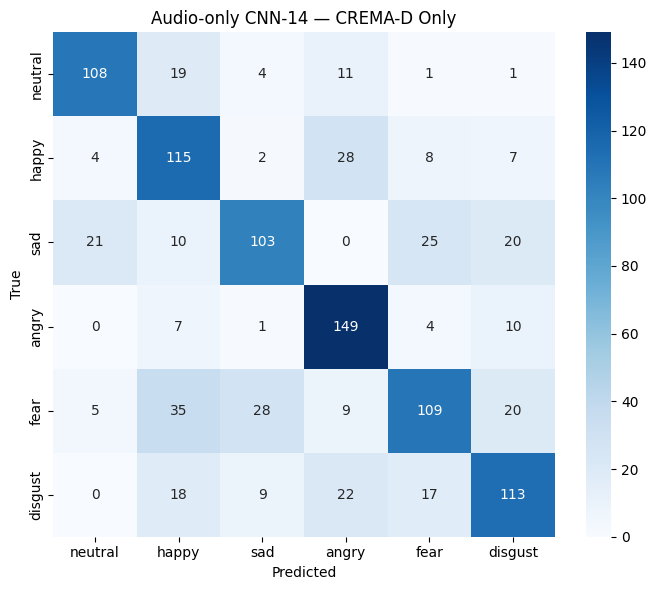

In [36]:
# --- Experiment: Train and Evaluate ONLY on CREMA-D ---
import shutil
import subprocess
from pathlib import Path

print("\n" + "="*50)
print("=== EXPERIMENT: CREMA-D ONLY ===")
print("="*50 + "\n")

# --- FIX FOR SLOW TRAINING: Use Local Colab Disk ---
DRIVE_CACHE = Path('/content/drive/MyDrive/Multimodal_Emotion_Detection_Project/mel_cache')
LOCAL_CACHE = Path('/content/local_mel_cache')

if DRIVE_CACHE.exists():
    print("Optimizing I/O: Copying mel cache from Google Drive to fast local disk...")
    # Using shutil.copytree for fast bulk copy (dirs_exist_ok allows it to resume/overwrite)
    shutil.copytree(DRIVE_CACHE, LOCAL_CACHE, dirs_exist_ok=True)
    print("Done copying to local disk! Training will now be much faster.\n")

# Override the global cache path function to read from local storage instead
def fast_get_mel_cache_path(audio_path: str) -> Path:
    import hashlib
    h = hashlib.md5(audio_path.encode()).hexdigest()
    return LOCAL_CACHE / f'{h}.pt'

# Inject this into the notebook's globals so the previously defined EmotionDataset uses it
globals()['get_mel_cache_path'] = fast_get_mel_cache_path
# ---------------------------------------------------


# 1. Filter datasets for CREMA-D only
train_cd_df = train_df[train_df['source'] == 'cremad'].reset_index(drop=True)
val_cd_df   = val_df[val_df['source'] == 'cremad'].reset_index(drop=True)
test_cd_df  = test_df[test_df['source'] == 'cremad'].reset_index(drop=True)

print(f"CREMA-D Train samples: {len(train_cd_df)}")
print(f"CREMA-D Val samples:   {len(val_cd_df)}")
print(f"CREMA-D Test samples:  {len(test_cd_df)}")

# 2. Rebuild Datasets and DataLoaders
# Using num_workers=2 and pin_memory=True to fetch batches asynchronously
train_cd_ds = EmotionDataset(train_cd_df, transcript_cache, use_text=use_text, apply_augmentation=True)
val_cd_ds   = EmotionDataset(val_cd_df,   transcript_cache, use_text=use_text, apply_augmentation=False)
test_cd_ds  = EmotionDataset(test_cd_df,  transcript_cache, use_text=use_text, apply_augmentation=False)

train_cd_loader = DataLoader(train_cd_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate, num_workers=2, pin_memory=True)
val_cd_loader   = DataLoader(val_cd_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate, num_workers=2, pin_memory=True)
test_cd_loader  = DataLoader(test_cd_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate, num_workers=2, pin_memory=True)

# Save original globals that the training/eval functions rely on
orig_test_loader = globals().get('test_loader')
orig_train_df = globals().get('train_df')

try:
    # Override globals for the train_model (needs train_df for weights)
    # and test_report (needs test_loader) functions
    globals()['test_loader'] = test_cd_loader
    globals()['train_df'] = train_cd_df

    # 3. Build a fresh model
    model_cd = build_model('audio')

    # Initialize runs dictionary if it doesn't exist
    if 'runs' not in globals():
        globals()['runs'] = {}

    # 4. Train the model
    best_cd_ckpt = train_model(model_cd, train_cd_loader, val_cd_loader, 'audio_cremad_only')
    runs['audio_cremad_only'] = str(best_cd_ckpt)

    # 5. Evaluate
    print("\n--- Evaluating CREMA-D Only Model ---")
    test_report('audio', best_cd_ckpt, 'Audio-only CNN-14 — CREMA-D Only')

finally:
    # Restore globals so we don't break subsequent cells
    if orig_test_loader is not None:
        globals()['test_loader'] = orig_test_loader
    if orig_train_df is not None:
        globals()['train_df'] = orig_train_df

In [37]:
# Extract frozen Wav2Vec2 features for train/val
model = build_model('audio').to(device)
model.eval()
def extract_features(loader):
    feats, labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = to_device(batch, device)
            # get the pooled hidden state (the penultimate layer)
            outputs = model.model.wav2vec2(
                input_values=batch.audio_input_values,
                attention_mask=batch.audio_attention_mask,
            )
            pooled = torch.mean(outputs.last_hidden_state, dim=1)  # (B, 768)
            feats.append(pooled.cpu().numpy())
            labels.append(batch.labels.cpu().numpy())
    return np.concatenate(feats), np.concatenate(labels)

train_feats, train_labels = extract_features(train_loader)
val_feats, val_labels = extract_features(val_loader)

# Train a simple logistic regression on these frozen features
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000)
clf.fit(train_feats, train_labels)
val_pred = clf.predict(val_feats)
print("Logistic regression on frozen features:")
print(classification_report(val_labels, val_pred, target_names=EMOTIONS))

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AttributeError: 'Wav2Vec2ForSequenceClassification' object has no attribute 'model'

In [ ]:
print("=== Split sanity check ===")
print(f"Train samples: {len(train_df)}")
print(f"Val samples:   {len(val_df)}")
print(f"Test samples:  {len(test_df)}")

print("\n=== Emotion distribution in train ===")
print(train_df['emotion'].value_counts())

print("\n=== Emotion distribution in val ===")
print(val_df['emotion'].value_counts())

print("\n=== Source distribution ===")
print("Train:", train_df['source'].value_counts().to_dict())
print("Val:  ", val_df['source'].value_counts().to_dict())

print("\n=== Actor overlap check ===")
train_actors = set(train_df['actor_id'].unique())
val_actors = set(val_df['actor_id'].unique())
print(f"Train actors: {sorted(train_actors)}")
print(f"Val actors:   {sorted(val_actors)}")
print(f"Overlap: {train_actors & val_actors}")

In [ ]:
model_for_eval = build_model('audio')
model_for_eval = load_checkpoint(model_for_eval, runs['audio_only']).to(device)
train_eval = eval_epoch(model_for_eval, train_loader)
print("Train accuracy:", train_eval['acc'])
print(classification_report(train_eval['y_true'], train_eval['y_pred'], target_names=EMOTIONS))

In [ ]:
import random
from IPython.display import Audio, display

print("\n--- Sample Audio and Text Alignment Check ---")

# Select a random index from the training dataframe directly
random_idx = random.randint(0, len(train_df) - 1)

# Retrieve the item using the dataframe and cache
row = train_df.iloc[random_idx]
audio_path = row['path']
label = row['label']
text_transcript = transcript_cache.get(audio_path, "[No transcript found in cache]")

print(f"Audio Path: {audio_path}")
print(f"Transcript: {text_transcript}")
print(f"Emotion: {ID2EMO[label]}")

# Play the audio directly from the file path
display(Audio(filename=audio_path))


## Notes: DataLoaders → Models (Wav2Vec2/RoBERTa) → Training/Eval
This big cell builds the datasets/loaders, defines the encoders + classifier heads, trains models, and evaluates on the held-out test set.

### Data flow (high level)
- Audio: waveform → SpecAugment (time/freq masking) → `Wav2Vec2FeatureExtractor` → `Wav2Vec2Model` → masked mean pooling
- Text (optional): transcript (or label-informed fallback if empty) → RoBERTa tokenizer → `AutoModel` → masked mean pooling
- Fusion: learned gating to blend pooled audio & pooled text → deeper MLP head (Dropout 0.3) → 6-class logits

### Important implementation details
- **Mask pooling for Wav2Vec2:** attention mask is originally sample-level; we interpolate it to frame-level before pooling.
- **Speaker-independent split:** if enabled, test speakers are unseen during training.
- **Class imbalance & Loss:** uses inverse-frequency class weights + label-smoothing (0.05) in the loss.
- **Wav2Vec2 Feature Extractor (Frozen):** The `facebook/wav2vec2-base` model is now used as a frozen feature extractor. The encoder parameters are frozen (`requires_grad = False`) and features are extracted using `torch.no_grad()`. This leverages the rich pre-trained features without fine-tuning the large encoder, speeding up training and improving stability.
- **Optimizer:** Uses `torch.optim.AdamW` with a learning rate of `3e-5` and `weight_decay=0.01` to stabilize training on the frozen features.

### Model selection / checkpoints
- Saves best checkpoint by **validation macro-F1** (more reliable than accuracy on imbalanced labels).
- **Early stopping:** Halts training if validation macro-F1 doesn't improve after 5 epochs to prevent overfitting.
- Checkpoints are saved as raw `state_dict()` to avoid PyTorch pickle/weights-only issues.
- Outputs: `OUTPUT_DIR/*_best_state_dict.pt` and `OUTPUT_DIR/checkpoints.json`.

### Debug / speed knobs
- Reduce compute: `NUM_EPOCHS=2`, `BATCH_SIZE=4`, `WHISPER_MODEL='tiny'`.
- Skip text: set `USE_WHISPER_TRANSCRIPTS=False` in config and rerun this cell.